# Covid 19 Data Wrangling and Cleaning

## Contents:

* Imports
* Initial look at data
* Cleaning data
* Conclusion about outliers

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

#from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

from sklearn.preprocessing import MinMaxScaler

#import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense


from math import sqrt
from sklearn.metrics import mean_squared_error

## Initial look at data

In [2]:
#Loading the data
df = pd.read_csv('../Data/us_states_covid19_daily.csv')

In [3]:
df.head()

,date,state,positive,probableCases,negative,pending,totalTestResultsSource,totalTestResults,hospitalizedCurrently,hospitalizedCumulative,...,posNeg,deathIncrease,hospitalizedIncrease,hash,commercialScore,negativeRegularScore,negativeScore,positiveScore,score,grade
0,20201206,AK,35720.0,NaN,1042056.0,NaN,totalTestsViral,1077776.0,164.0,799.0,...,1077776,0,0,7b1d31e2756687bb9259b29195f1db6cdb321ea6,0,0,0,0,0,NaN
1,20201206,AL,269877.0,45962.0,1421126.0,NaN,totalTestsPeopleViral,1645041.0,1927.0,26331.0,...,1691003,12,0,19454ed8fe28fc0a7948fc0771b2f3c846c1c92e,0,0,0,0,0,NaN
2,20201206,AR,170924.0,22753.0,1614979.0,NaN,totalTestsViral,1763150.0,1076.0,9401.0,...,1785903,40,21,25fc83bffff5b32ba1a737be8e087fad9f4fde33,0,0,0,0,0,NaN
3,20201206,AS,0.0,NaN,2140.0,NaN,totalTestsViral,2140.0,NaN,NaN,...,2140,0,0,8c39eec317586b0c34fc2903e6a3891ecb00469e,0,0,0,0,0,NaN
4,20201206,AZ,364276.0,12590.0,2018813.0,NaN,totalTestsPeopleViral,2370499.0,2977.0,28248.0,...,2383089,25,242,7cf59da9e4bc31d905e179211313d08879880a85,0,0,0,0,0,NaN


In [4]:
df.shape

(15633, 55)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15633 entries, 0 to 15632
Data columns (total 55 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         15633 non-null  int64  
 1   state                        15633 non-null  object 
 2   positive                     15481 non-null  float64
 3   probableCases                5449 non-null   float64
 4   negative                     15323 non-null  float64
 5   pending                      1684 non-null   float64
 6   totalTestResultsSource       15633 non-null  object 
 7   totalTestResults             15598 non-null  float64
 8   hospitalizedCurrently        12516 non-null  float64
 9   hospitalizedCumulative       9434 non-null   float64
 10  inIcuCurrently               7713 non-null   float64
 11  inIcuCumulative              2700 non-null   float64
 12  onVentilatorCurrently        6211 non-null   float64
 13  onVentilatorCumu

In [6]:
df.isna().sum()

date                               0
state                              0
positive                         152
probableCases                  10184
negative                         310
pending                        13949
totalTestResultsSource             0
totalTestResults                  35
hospitalizedCurrently           3117
hospitalizedCumulative          6199
inIcuCurrently                  7920
inIcuCumulative                12933
onVentilatorCurrently           9422
onVentilatorCumulative         14704
recovered                       4522
dataQualityGrade                1261
lastUpdateEt                     487
dateModified                     487
checkTimeEt                      487
death                            826
hospitalized                    6199
dateChecked                      487
totalTestsViral                 5812
positiveTestsViral             10621
negativeTestsViral             12318
positiveCasesViral              3516
deathConfirmed                  8783
d

In [7]:
df.describe()

,date,positive,probableCases,negative,pending,totalTestResults,hospitalizedCurrently,hospitalizedCumulative,inIcuCurrently,inIcuCumulative,...,totalTestResultsIncrease,posNeg,deathIncrease,hospitalizedIncrease,commercialScore,negativeRegularScore,negativeScore,positiveScore,score,grade
count,1.563300e+04,1.548100e+04,5449.000000,1.532300e+04,1684.000000,1.559800e+04,12516.000000,9434.000000,7713.000000,2700.000000,...,15633.000000,1.563300e+04,15633.000000,15633.000000,15633.0,15633.0,15633.0,15633.0,15633.0,0.0
mean,2.020073e+07,8.192476e+04,5132.611488,9.830243e+05,1492.718527,1.159400e+06,942.667705,8156.948590,305.377026,1368.261852,...,13052.927269,1.044659e+06,17.486983,37.463827,0.0,0.0,0.0,0.0,0.0,NaN
std,2.653114e+02,1.498767e+05,8372.729572,2.094830e+06,5032.866393,2.326293e+06,1585.640390,15230.676264,502.551557,1325.765418,...,25378.395705,2.209745e+06,43.364168,230.386136,0.0,0.0,0.0,0.0,0.0,NaN
min,2.020012e+07,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000,0.000000,6.000000,...,-336892.000000,0.000000e+00,-213.000000,-4124.000000,0.0,0.0,0.0,0.0,0.0,NaN
25%,2.020051e+07,2.817000e+03,464.000000,5.044200e+04,29.000000,5.151775e+04,135.000000,680.250000,59.000000,363.750000,...,788.000000,4.737700e+04,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,NaN
50%,2.020072e+07,2.313400e+04,2108.000000,2.951530e+05,195.000000,3.532310e+05,464.000000,3016.500000,148.000000,990.000000,...,4638.000000,3.095820e+05,4.000000,0.000000,0.0,0.0,0.0,0.0,0.0,NaN
75%,2.020093e+07,9.694200e+04,6259.000000,9.829570e+05,991.000000,1.192387e+06,1013.000000,9338.750000,315.000000,1849.750000,...,13946.000000,1.056107e+06,17.000000,31.000000,0.0,0.0,0.0,0.0,0.0,NaN
max,2.020121e+07,1.341700e+06,100964.000000,2.385335e+07,64400.000000,2.519505e+07,18825.000000,89995.000000,5225.000000,6676.000000,...,958213.000000,2.519505e+07,951.000000,16373.000000,0.0,0.0,0.0,0.0,0.0,NaN


In [8]:
df['state'].unique()

array(['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL',
       'GA', 'GU', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA',
       'MD', 'ME', 'MI', 'MN', 'MO', 'MP', 'MS', 'MT', 'NC', 'ND', 'NE',
       'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI',
       'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VI', 'VT', 'WA', 'WI', 'WV',
       'WY'], dtype=object)

In [9]:
#Checking for columns
df.columns

Index(['date', 'state', 'positive', 'probableCases', 'negative', 'pending',
       'totalTestResultsSource', 'totalTestResults', 'hospitalizedCurrently',
       'hospitalizedCumulative', 'inIcuCurrently', 'inIcuCumulative',
       'onVentilatorCurrently', 'onVentilatorCumulative', 'recovered',
       'dataQualityGrade', 'lastUpdateEt', 'dateModified', 'checkTimeEt',
       'death', 'hospitalized', 'dateChecked', 'totalTestsViral',
       'positiveTestsViral', 'negativeTestsViral', 'positiveCasesViral',
       'deathConfirmed', 'deathProbable', 'totalTestEncountersViral',
       'totalTestsPeopleViral', 'totalTestsAntibody', 'positiveTestsAntibody',
       'negativeTestsAntibody', 'totalTestsPeopleAntibody',
       'positiveTestsPeopleAntibody', 'negativeTestsPeopleAntibody',
       'totalTestsPeopleAntigen', 'positiveTestsPeopleAntigen',
       'totalTestsAntigen', 'positiveTestsAntigen', 'fips', 'positiveIncrease',
       'negativeIncrease', 'total', 'totalTestResultsIncrease', 'posNe

## Cleaning Data

In [10]:
#Converting 'date' column to datime format to prepared for a time series analysis
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')


In [11]:
# Set 'date' index
df.set_index('date')

,state,positive,probableCases,negative,pending,totalTestResultsSource,totalTestResults,hospitalizedCurrently,hospitalizedCumulative,inIcuCurrently,...,posNeg,deathIncrease,hospitalizedIncrease,hash,commercialScore,negativeRegularScore,negativeScore,positiveScore,score,grade
date,,,,,,,,,,,,,,,,,,,,,
2020-12-06,AK,35720.0,NaN,1042056.0,NaN,totalTestsViral,1077776.0,164.0,799.0,NaN,...,1077776,0,0,7b1d31e2756687bb9259b29195f1db6cdb321ea6,0,0,0,0,0,NaN
2020-12-06,AL,269877.0,45962.0,1421126.0,NaN,totalTestsPeopleViral,1645041.0,1927.0,26331.0,NaN,...,1691003,12,0,19454ed8fe28fc0a7948fc0771b2f3c846c1c92e,0,0,0,0,0,NaN
2020-12-06,AR,170924.0,22753.0,1614979.0,NaN,totalTestsViral,1763150.0,1076.0,9401.0,374.0,...,1785903,40,21,25fc83bffff5b32ba1a737be8e087fad9f4fde33,0,0,0,0,0,NaN
2020-12-06,AS,0.0,NaN,2140.0,NaN,totalTestsViral,2140.0,NaN,NaN,NaN,...,2140,0,0,8c39eec317586b0c34fc2903e6a3891ecb00469e,0,0,0,0,0,NaN
2020-12-06,AZ,364276.0,12590.0,2018813.0,NaN,totalTestsPeopleViral,2370499.0,2977.0,28248.0,714.0,...,2383089,25,242,7cf59da9e4bc31d905e179211313d08879880a85,0,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-24,WA,0.0,NaN,0.0,NaN,totalTestEncountersViral,0.0,NaN,NaN,NaN,...,0,0,0,82726df68eb97c98a4a6ee792349e547023147d5,0,0,0,0,0,NaN
2020-01-23,MA,NaN,NaN,NaN,NaN,totalTestsViral,2.0,NaN,NaN,NaN,...,0,0,0,76bc987d054b119a4e05a4a43742249c0b0568b6,0,0,0,0,0,NaN
2020-01-23,WA,0.0,NaN,0.0,NaN,totalTestEncountersViral,0.0,NaN,NaN,NaN,...,0,0,0,1c2229c239ffad5e5fdd9d76c641dc9166caf6ba,0,0,0,0,0,NaN


In [12]:
#Checking the period of time that dataset cover

unique_dates = df['date'].unique()

start_date = unique_dates.min()
end_date = unique_dates.max()

print(f"The data set covers the period from {start_date} to {end_date}.")

The data set covers the period from 2020-01-22T00:00:00.000000000 to 2020-12-06T00:00:00.000000000.


In [13]:
#Removing hours from dataset

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

    if not df['date'].empty:
        df['date'] = df['date'].dt.strftime('%Y-%m-%d')  # Format as YYYY-MM-DD

        start_date = df['date'].min()
        end_date = df['date'].max()
        print(f"The data set covers the period from {start_date} to {end_date}.")
    else:
        print("No valid dates found in the 'date' column.")
else:
    print("The 'date' column is not present in the DataFrame.")


The data set covers the period from 2020-01-22 to 2020-12-06.


In [14]:
#Handling missing values
threshold = 0.8
columns_to_keep = df.columns[df.isna().mean() < threshold]
print('Columns to keep:', columns_to_keep)
df = df[columns_to_keep]

Columns to keep: Index(['date', 'state', 'positive', 'probableCases', 'negative',
       'totalTestResultsSource', 'totalTestResults', 'hospitalizedCurrently',
       'hospitalizedCumulative', 'inIcuCurrently', 'onVentilatorCurrently',
       'recovered', 'dataQualityGrade', 'lastUpdateEt', 'dateModified',
       'checkTimeEt', 'death', 'hospitalized', 'dateChecked',
       'totalTestsViral', 'positiveTestsViral', 'negativeTestsViral',
       'positiveCasesViral', 'deathConfirmed', 'deathProbable',
       'totalTestEncountersViral', 'totalTestsPeopleViral', 'fips',
       'positiveIncrease', 'negativeIncrease', 'total',
       'totalTestResultsIncrease', 'posNeg', 'deathIncrease',
       'hospitalizedIncrease', 'hash', 'commercialScore',
       'negativeRegularScore', 'negativeScore', 'positiveScore', 'score'],
      dtype='object')


In [15]:
#Impute missing values in specific columsn:
df['positive'].fillna(df['positive'].mean(),inplace=True)
df['negative'].fillna(df['negative'].mean(),inplace=True)
df['death'].fillna(df['death'].mean(),inplace=True)


In [16]:
#Hangling duplicate rows
df = df.drop_duplicates()

In [17]:
#Select relevant columns
selected_columns = ['date','state','positive','negative','death']
df = df[selected_columns]

In [18]:
#Set 'date'as index
df.set_index('date',inplace=True)
df.head()

,state,positive,negative,death
date,,,,
2020-12-06,AK,35720.0,1042056.0,143.0
2020-12-06,AL,269877.0,1421126.0,3889.0
2020-12-06,AR,170924.0,1614979.0,2660.0
2020-12-06,AS,0.0,2140.0,0.0
2020-12-06,AZ,364276.0,2018813.0,6950.0


In [19]:
#Looking for potential outliers quantitatively
positive_stats = df['positive'].describe()
negative_stats = df['negative'].describe()
death_stats = df['death'].describe()

print('positive Cases Statistics:\n', positive_stats)
print('\nnegtive Statistics:\n',negative_stats)
print('\nDeath Statistics:\n',death_stats)

positive Cases Statistics:
 count    1.563300e+04
mean     8.192476e+04
std      1.491463e+05
min      0.000000e+00
25%      2.914000e+03
50%      2.387000e+04
75%      9.565900e+04
max      1.341700e+06
Name: positive, dtype: float64

negtive Statistics:
 count    1.563300e+04
mean     9.830243e+05
std      2.073955e+06
min      0.000000e+00
25%      5.331000e+04
50%      3.059720e+05
75%      9.830243e+05
max      2.385335e+07
Name: negative, dtype: float64

Death Statistics:
 count    15633.000000
mean      2495.210914
std       4365.769373
min          0.000000
25%        109.000000
50%        746.000000
75%       2526.000000
max      27149.000000
Name: death, dtype: float64


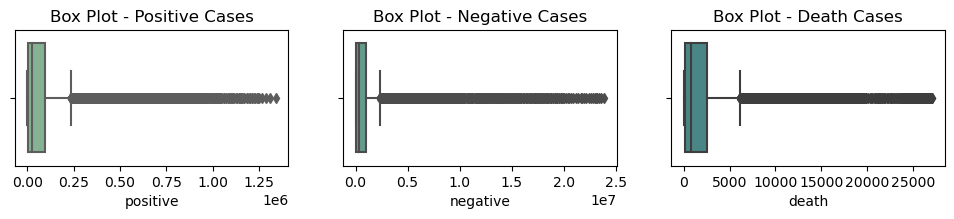

In [20]:
#Set the color
crest_palette = sns.color_palette('crest')

# Visualize the data
plt.figure(figsize=(12, 6))

plt.subplot(3, 3, 1)
sns.boxplot(data=df, x='positive', color=crest_palette[0])
plt.title('Box Plot - Positive Cases')

plt.subplot(3, 3, 2)
sns.boxplot(data=df, x='negative', color=crest_palette[1])
plt.title('Box Plot - Negative Cases')

plt.subplot(3, 3, 3)
sns.boxplot(data=df, x='death', color=crest_palette[2])
plt.title('Box Plot - Death Cases')

plt.show()


In [21]:
#Calculate Z-Score to identify outliers
from scipy import stats

z_scores_positive = stats.zscore(df['positive'])
outliers_positive = (z_scores_positive > 3) | (z_scores_positive < -3)

z_scores_negative = stats.zscore(df['negative'])
outliers_negative = (z_scores_negative > 3) | (z_scores_negative < -3)

z_scores_death = stats.zscore(df['death'])
outliers_death = (z_scores_death > 3) | (z_scores_death < -3)

# Print the number of outliers
print('Number of outliers in Positive Cases:', sum(outliers_positive))
print('Number of outliers in Negative Cases:', sum(outliers_negative))
print('Number of outliers in Death Cases:', sum(outliers_death))


Number of outliers in Positive Cases: 407
Number of outliers in Negative Cases: 309
Number of outliers in Death Cases: 559


## Conclusion about outliers

In summary, the choice of outlier-handling method should be tailored to my data and analysis goals. Experiment with different approaches, evaluate model performance, and select the method that aligns best with my dataset's characteristics.

In [22]:
df.to_csv('cleaned_data.csv')